In [1]:
#===============================================================================
#   図　6.8  ハイパーパラメータ系列の3次元分布 (濃いカラーバーを表示)
#
#   Copyright (c) 2024, Yuukou TOYONORI
#   All rights reserved.
#===============================================================================
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family']      = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['text.usetex']      = True
plt.rcParams['font.size']        = 12
plt.rcParams['axes.labelsize']   = 'xx-large'

In [2]:
def Kernel(x, x_prime, noise, thetas):
    return thetas[0] * np.exp(-(x - x_prime) ** 2 / thetas[1]) + noise * thetas[2]

def log_likely(params):
    train_length = len(x_train)
    K = np.zeros((train_length, train_length))
    for x_idx in range(train_length):
        for x_prime_idx in range(train_length):
            K[x_idx, x_prime_idx] = Kernel(x_train[x_idx], x_train[x_prime_idx], x_idx == x_prime_idx, params)
    y  = y_train
    yy = np.dot(np.linalg.inv(K), y_train)
    return - (10*np.log(2*np.pi) + np.linalg.slogdet(K)[1] + np.dot(y, yy))/2

In [3]:
def MCMC(x_train, y_train, bounds, initial_params=np.ones(3), n_iter=40000):
    params     = initial_params
    log_params = np.log(params)
    log_bounds = np.log(bounds)
    log_scale  = log_bounds[:, 1] - log_bounds[:, 0]
    #
    lml_prev   = log_likely(params)
    theta_list = np.array([])
    lml_list   = np.array([])
    # %%    
    for _ in range(n_iter):
        move = 1e-2 * np.random.normal(0, log_scale, size=len(params))
        need_resample = (log_params + move < log_bounds[:, 0]) | \
                        (log_params + move > log_bounds[:, 1])
        while(np.any(need_resample)):
            move[need_resample] = np.random.normal(0, log_scale, size=len(params))[need_resample]
            need_resample = (log_params + move < log_bounds[:, 0]) | \
                            (log_params + move > log_bounds[:, 1])
        # create proposed distribution
        next_log_params = log_params + move
        next_params     = np.exp(next_log_params)
        lml_next        = log_likely(next_params)
        r               = np.exp(lml_next - lml_prev)
        # metropolis update
        if r > 1 or r > np.random.random():
            params      = next_params
            log_params  = next_log_params
            lml_prev    = lml_next
            theta_list = np.append(theta_list, params)
            lml_list    = np.append(lml_list, lml_prev)
    theta_list = theta_list.reshape(len(lml_list), 3)
    return (theta_list, lml_list)

In [4]:
x_train = np.array([ 0.00,  0.22,  0.44,  0.67,  0.90,  0.16,  0.34,  0.50,  0.73,  1.00 ])
y_train = np.array([-0.06,  0.97,  0.25, -0.90, -0.53,  0.94,  0.85,  0.09, -0.93,  0.08 ])
x_test  = np.linspace(-0.2, 1.2, 241)
#
np.random.seed(0)
theta_list, lml_list = MCMC(x_train, y_train, 
                         bounds=np.array([[1e-4, 1e2], [1e-4, 1e2], [1e-4, 1e2]]), 
                         initial_params=np.array([0.5, 0.5, 0.5]))

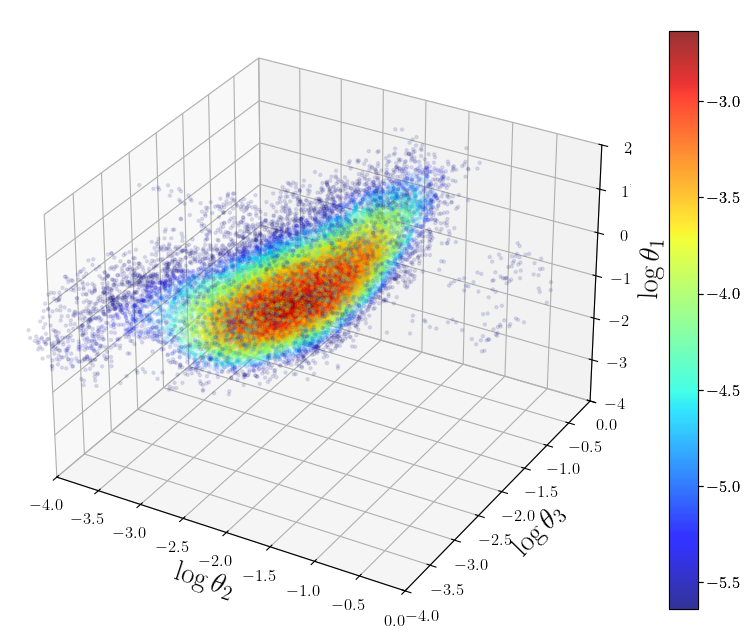

In [5]:
fig = plt.figure(figsize=(10, 10), dpi=100) 
ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax2 = fig.add_subplot(1, 1, 1, projection='3d')
mp1 = ax1.scatter(np.log(theta_list[:, 1]),
                 np.log(np.sqrt(theta_list[:, 2] / 2)),
                 np.log(theta_list[:, 0]), 
                 c=lml_list, cmap='jet', alpha=0.8, s=1,
                 vmin=lml_list.max()-3, vmax=lml_list.max())
mp2 = ax2.scatter(np.log(theta_list[:, 1]),
                 np.log(np.sqrt(theta_list[:, 2] / 2)),
                 np.log(theta_list[:, 0]), 
                 c=lml_list, cmap='jet', alpha=0.1, s=5,
                 vmin=lml_list.max()-3, vmax=lml_list.max())
ax2.set_xlim([-4., 0.])
ax2.set_ylim([-4., 0.])    
ax2.set_zlim([-4., 2.])    
ax2.set_xlabel(r'$\log \theta_2$')
ax2.set_ylabel(r'$\log \theta_3$')
ax2.set_zlabel(r'$\log \theta_1$')
plt.colorbar(mp2, ax=ax2, shrink=0.75)
plt.colorbar(mp1, ax=ax1, shrink=0.75)
plt.show()